# Data Exploration — Track A Datasets
Covers the five CSV sources that feed the SQLite database:
1. `area-wise tele density.csv`
2. `education-enrolment.csv`
3. `digital transactions.csv`
4. `sector-wise electricity consumption.csv`
5. `wired, wireless telephone.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path('../datasets')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Area-wise Tele Density

In [2]:
td = pd.read_csv(DATA / 'area-wise tele density.csv')
print('Shape:', td.shape)
td.head()

Shape: (2100, 5)


,Country,Year,Month,Service Area,"Tele-Density Service Area-Wise (UOM:Number), Scaling Factor:1000000"
0,India,"Financial Year (Apr - Mar), 2023","November, 2023",Andhra Pradesh,93.46
1,India,"Financial Year (Apr - Mar), 2023","November, 2023",Assam,72.11
2,India,"Financial Year (Apr - Mar), 2023","November, 2023",Bihar,56.18
3,India,"Financial Year (Apr - Mar), 2023","November, 2023",Gujarat,91.88
4,India,"Financial Year (Apr - Mar), 2023","November, 2023",Haryana,88.68


In [3]:
td.dtypes

Country                                                                 object
Year                                                                    object
Month                                                                   object
Service Area                                                            object
Tele-Density Service Area-Wise (UOM:Number), Scaling Factor:1000000    float64
dtype: object

In [4]:
# Rename long column for convenience
td.columns = ['country', 'year_raw', 'month_raw', 'service_area', 'tele_density']

print('Unique year_raw values:')
print(sorted(td['year_raw'].unique()))

Unique year_raw values:
['Financial Year (Apr - Mar), 2013', 'Financial Year (Apr - Mar), 2014', 'Financial Year (Apr - Mar), 2015', 'Financial Year (Apr - Mar), 2016', 'Financial Year (Apr - Mar), 2017', 'Financial Year (Apr - Mar), 2018', 'Financial Year (Apr - Mar), 2019', 'Financial Year (Apr - Mar), 2020', 'Financial Year (Apr - Mar), 2021', 'Financial Year (Apr - Mar), 2022', 'Financial Year (Apr - Mar), 2023']


In [5]:
print('Unique month_raw samples:')
print(td['month_raw'].unique()[:10])

Unique month_raw samples:
['November, 2023' 'October, 2023' 'September, 2023' 'August, 2023'
 'July, 2023' 'June, 2023' 'May, 2023' 'April, 2023' 'March, 2023'
 'February, 2023']


In [6]:
print('Unique service areas (telecom circles):')
print(sorted(td['service_area'].unique()))

Unique service areas (telecom circles):
['Andhra Pradesh', 'Assam', 'Bihar', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Karnataka', 'Kerala', 'Kolkata', 'Madhya Pradesh', 'Maharashtra', 'Mumbai', 'North East', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


In [7]:
print('Missing values:')
print(td.isnull().sum())
print('\nBasic stats:')
td['tele_density'].describe()

Missing values:
country         0
year_raw        0
month_raw       0
service_area    0
tele_density    0
dtype: int64

Basic stats:


count    2100.000000
mean      105.078071
std        44.508269
min        46.100000
25%        75.260000
50%        93.850000
75%       121.422500
max       282.010000
Name: tele_density, dtype: float64

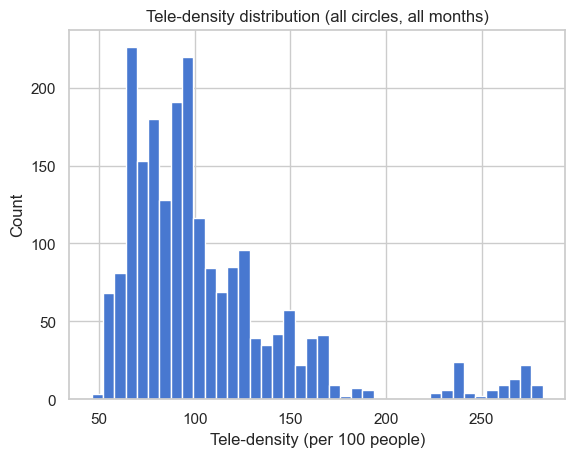

In [8]:
# Quick look at distribution
td['tele_density'].hist(bins=40)
plt.title('Tele-density distribution (all circles, all months)')
plt.xlabel('Tele-density (per 100 people)')
plt.ylabel('Count')
plt.show()

## 2. Education Enrolment (GER)

In [9]:
ed = pd.read_csv(DATA / 'education-enrolment.csv')
print('Shape:', ed.shape)
ed.head()

Shape: (3231, 6)


,Country,State,Year,Gender,Category,"Gross Enrolment Ratio (Ger) In Higher Education (UOM:Ratio), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2021",Male,All Categories,19.8
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2021",Female,All Categories,25.7
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2021",Total,All Categories,22.6
3,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2021",Male,Scheduled Caste,NaN
4,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2021",Female,Scheduled Caste,NaN


In [10]:
ed.columns = ['country', 'state', 'year_raw', 'gender', 'category', 'ger']

print('Year range:', sorted(ed['year_raw'].unique()))

Year range: ['Financial Year (Apr - Mar), 2012', 'Financial Year (Apr - Mar), 2013', 'Financial Year (Apr - Mar), 2014', 'Financial Year (Apr - Mar), 2015', 'Financial Year (Apr - Mar), 2016', 'Financial Year (Apr - Mar), 2017', 'Financial Year (Apr - Mar), 2018', 'Financial Year (Apr - Mar), 2019', 'Financial Year (Apr - Mar), 2020', 'Financial Year (Apr - Mar), 2021']


In [11]:
print('Unique states:')
print(sorted(ed['state'].unique()))

Unique states:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'The Dadra And Nagar Haveli And Daman And Diu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [12]:
print('Gender values:', ed['gender'].unique())
print('Category values:', ed['category'].unique())

Gender values: ['Male' 'Female' 'Total']
Category values: ['All Categories' 'Scheduled Caste' 'Scheduled Tribe']


In [13]:
print('Missing GER values:', ed['ger'].isnull().sum())
print('Missing by state (top 15):')
ed[ed['ger'].isnull()].groupby('state').size().sort_values(ascending=False).head(15)

Missing GER values: 270
Missing by state (top 15):


state
Andaman And Nicobar Islands    30
Arunachal Pradesh              30
Chandigarh                     30
Delhi                          30
Haryana                        30
Lakshadweep                    30
Nagaland                       30
Puducherry                     30
Punjab                         30
dtype: int64

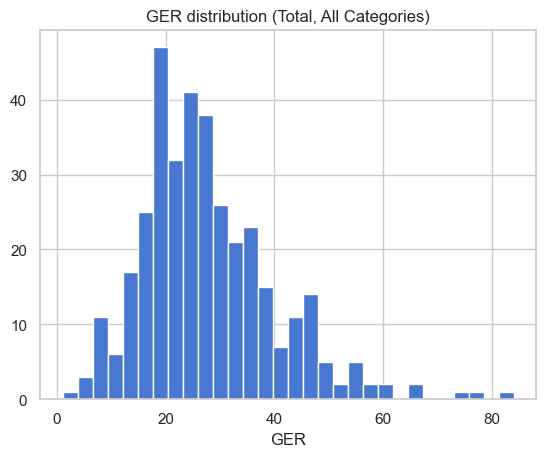

In [14]:
# GER distribution for Total / All Categories
total = ed[(ed['gender'] == 'Total') & (ed['category'] == 'All Categories')]
total['ger'].dropna().hist(bins=30)
plt.title('GER distribution (Total, All Categories)')
plt.xlabel('GER')
plt.show()

In [15]:
# States vs telecom circles — unique state names
print('States in education data that need mapping to telecom circles:')
print(sorted(ed['state'].unique()))

States in education data that need mapping to telecom circles:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'The Dadra And Nagar Haveli And Daman And Diu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


## 3. Digital Transactions

In [16]:
dt = pd.read_csv(DATA / 'digital transactions.csv')
print('Shape:', dt.shape)
dt.head(10)

Shape: (64, 8)


,Country,Year,Month,Name Of The Ministry,Name Of The Project,"Digital Transaction (UOM:INR(IndianRupees)), Scaling Factor:10000000","Bhim Transaction (UOM:INR(IndianRupees)), Scaling Factor:10000000","Debit Card (UOM:INR(IndianRupees)), Scaling Factor:10000000"
0,India,"Calendar Year (Jan - Dec), 2022","July, 2022",Ministry of Electronics and Information Techno...,Digital Payments,953.91,586.38,32.88
1,India,"Calendar Year (Jan - Dec), 2022","June, 2022",Ministry of Electronics and Information Techno...,Digital Payments,914.38,586.27,31.82
2,India,"Calendar Year (Jan - Dec), 2022","May, 2022",Ministry of Electronics and Information Techno...,Digital Payments,1066.31,595.53,32.47
3,India,"Calendar Year (Jan - Dec), 2022","April, 2022",Ministry of Electronics and Information Techno...,Digital Payments,863.65,558.30,32.46
4,India,"Calendar Year (Jan - Dec), 2022","March, 2022",Ministry of Electronics and Information Techno...,Digital Payments,869.69,504.71,37.37
5,India,"Calendar Year (Jan - Dec), 2022","February, 2022",Ministry of Electronics and Information Techno...,Digital Payments,777.12,452.74,33.75
6,India,"Calendar Year (Jan - Dec), 2022","January, 2022",Ministry of Electronics and Information Techno...,Digital Payments,803.10,461.71,37.65
7,India,"Calendar Year (Jan - Dec), 2021","December, 2021",Ministry of Electronics and Information Techno...,Digital Payments,847.91,456.62,37.65
8,India,"Calendar Year (Jan - Dec), 2021","November, 2021",Ministry of Electronics and Information Techno...,Digital Payments,816.86,418.64,36.44
9,India,"Calendar Year (Jan - Dec), 2021","October, 2021",Ministry of Electronics and Information Techno...,Digital Payments,804.08,421.85,38.53


In [17]:
dt.columns = ['country', 'year_raw', 'month_raw', 'ministry', 'project', 'digital_txn_crores', 'bhim_txn_crores', 'debit_card_crores']
print('Year range:', sorted(dt['year_raw'].unique()))
print('Missing:', dt.isnull().sum())

Year range: ['Calendar Year (Jan - Dec), 2017', 'Calendar Year (Jan - Dec), 2018', 'Calendar Year (Jan - Dec), 2019', 'Calendar Year (Jan - Dec), 2020', 'Calendar Year (Jan - Dec), 2021', 'Calendar Year (Jan - Dec), 2022']
Missing: country               0
year_raw              0
month_raw             0
ministry              0
project               0
digital_txn_crores    0
bhim_txn_crores       0
debit_card_crores     0
dtype: int64


In [18]:
# Month raw samples
print('Month raw samples:', dt['month_raw'].unique())

Month raw samples: ['July, 2022' 'June, 2022' 'May, 2022' 'April, 2022' 'March, 2022'
 'February, 2022' 'January, 2022' 'December, 2021' 'November, 2021'
 'October, 2021' 'September, 2021' 'August, 2021' 'July, 2021'
 'June, 2021' 'May, 2021' 'April, 2021' 'March, 2021' 'February, 2021'
 'January, 2021' 'December, 2020' 'November, 2020' 'October, 2020'
 'September, 2020' 'August, 2020' 'July, 2020' 'June, 2020' 'May, 2020'
 'April, 2020' 'March, 2020' 'February, 2020' 'January, 2020'
 'December, 2019' 'November, 2019' 'October, 2019' 'September, 2019'
 'August, 2019' 'July, 2019' 'June, 2019' 'May, 2019' 'April, 2019'
 'March, 2019' 'February, 2019' 'January, 2019' 'December, 2018'
 'November, 2018' 'October, 2018' 'September, 2018' 'August, 2018'
 'July, 2018' 'June, 2018' 'May, 2018' 'April, 2018' 'March, 2018'
 'February, 2018' 'January, 2018' 'December, 2017' 'November, 2017'
 'October, 2017' 'September, 2017' 'August, 2017' 'July, 2017'
 'June, 2017' 'May, 2017' 'April, 2017']


In [19]:
dt[['digital_txn_crores', 'bhim_txn_crores', 'debit_card_crores']].describe()

,digital_txn_crores,bhim_txn_crores,debit_card_crores
count,64.000000,64.000000,64.000000
mean,433.863750,171.850625,35.068125
std,238.489914,173.195684,5.714014
min,152.900000,0.700000,20.950000
25%,241.570000,29.547500,31.592500
50%,389.500000,118.350000,35.800000
75%,546.805000,256.487500,38.585000
max,1066.310000,595.530000,46.370000


## 4. Sector-wise Electricity Consumption

In [20]:
elec = pd.read_csv(DATA / 'sector-wise electricity consumption.csv')
print('Shape:', elec.shape)
elec.head(10)

Shape: (158, 7)


,Country,Year,Type Of Sector,Additional Info,"Energy Consumption (UOM:Gwh(Gigawatthour)), Scaling Factor:1","Percentage Of Electricity Consumption In India (UOM:%(Percentage)), Scaling Factor:1","Percentage Of Annual Growth In India (UOM:%(Percentage)), Scaling Factor:1"
0,India,"Financial Year (Apr - Mar), 2023",Industry,Provisional,645000,41.80,8.61
1,India,"Financial Year (Apr - Mar), 2023",Agriculture,Provisional,255000,16.53,4.57
2,India,"Financial Year (Apr - Mar), 2023",Domestic,Provisional,375000,24.30,6.19
3,India,"Financial Year (Apr - Mar), 2023",Commercial,Provisional,125000,8.10,6.63
4,India,"Financial Year (Apr - Mar), 2023",Traction and Railways,Provisional,33000,2.14,9.90
5,India,"Financial Year (Apr - Mar), 2023",Electricity Consumed,Provisional,1543000,100.00,7.13
6,India,"Financial Year (Apr - Mar), 2023",Others,Provisional,110000,7.13,7.69
7,India,"Financial Year (Apr - Mar), 2022",Industry,NaN,595000,42.40,6.92
8,India,"Financial Year (Apr - Mar), 2022",Agriculture,NaN,240800,17.16,5.41
9,India,"Financial Year (Apr - Mar), 2022",Domestic,NaN,362000,25.79,6.54


In [21]:
elec.columns = ['country', 'year_raw', 'sector', 'additional_info', 'energy_gwh', 'pct_consumption', 'pct_growth']
print('Unique sectors:', elec['sector'].unique())
print('Year range:', sorted(elec['year_raw'].unique())[:5], '...', sorted(elec['year_raw'].unique())[-5:])
print('Missing:', elec.isnull().sum())

Unique sectors: ['Industry' 'Agriculture' 'Domestic' 'Commercial' 'Traction and Railways'
 'Electricity Consumed' 'Others']
Year range: ['Financial Year (Apr - Mar), 1970', 'Financial Year (Apr - Mar), 1980', 'Financial Year (Apr - Mar), 1985', 'Financial Year (Apr - Mar), 1990', 'Financial Year (Apr - Mar), 1995'] ... ['Financial Year (Apr - Mar), 2019', 'Financial Year (Apr - Mar), 2020', 'Financial Year (Apr - Mar), 2021', 'Financial Year (Apr - Mar), 2022', 'Financial Year (Apr - Mar), 2023']
Missing: country              0
year_raw             0
sector               0
additional_info    151
energy_gwh           0
pct_consumption      1
pct_growth          60
dtype: int64


In [22]:
elec[['energy_gwh', 'pct_consumption', 'pct_growth']].describe()

,energy_gwh,pct_consumption,pct_growth
count,1.580000e+02,157.000000,98.000000
mean,2.131537e+05,23.566561,6.933980
std,3.155296e+05,26.915342,6.288166
min,1.364000e+03,1.190000,-8.460000
25%,2.357625e+04,5.680000,3.495000
50%,8.649350e+04,16.930000,6.720000
75%,2.346768e+05,26.760000,8.620000
max,1.543000e+06,100.000000,34.990000


## 5. Wired / Wireless Telephone

In [23]:
ww = pd.read_csv(DATA / 'wired, wireless telephone.csv')
print('Shape:', ww.shape)
ww.head()

Shape: (1694, 7)


,Country,Year,Month,Service Area,"Number Of Wireline Telephones (UOM:Number), Scaling Factor:1000000","Number Of Wireless Telephones (UOM:Number), Scaling Factor:1000000","Percentage Share In Total Telephones (UOM:Percentage), Scaling Factor:1"
0,India,"Calendar Year (Jan - Dec), 2023","November, 2023",Andhra Pradesh,2.72,82.82,7.22
1,India,"Calendar Year (Jan - Dec), 2023","November, 2023",Assam,0.31,25.62,2.19
2,India,"Calendar Year (Jan - Dec), 2023","November, 2023",Bihar,0.83,93.54,7.96
3,India,"Calendar Year (Jan - Dec), 2023","November, 2023",Gujarat,1.42,66.10,5.70
4,India,"Calendar Year (Jan - Dec), 2023","November, 2023",Haryana,0.51,26.52,2.28


In [24]:
ww.columns = ['country', 'year_raw', 'month_raw', 'service_area', 'wireline_millions', 'wireless_millions', 'pct_share']
print('Unique service areas:')
print(sorted(ww['service_area'].unique()))
print('\nYear range:', sorted(ww['year_raw'].unique()))
print('Missing:', ww.isnull().sum())

Unique service areas:
['Andhra Pradesh', 'Assam', 'Bihar', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Karnataka', 'Kerala', 'Kolkata', 'Madhya Pradesh', 'Maharashtra', 'Mumbai', 'North East', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh (East)', 'Uttar Pradesh (West)', 'West Bengal']

Year range: ['Calendar Year (Jan - Dec), 2017', 'Calendar Year (Jan - Dec), 2018', 'Calendar Year (Jan - Dec), 2019', 'Calendar Year (Jan - Dec), 2020', 'Calendar Year (Jan - Dec), 2021', 'Calendar Year (Jan - Dec), 2022', 'Calendar Year (Jan - Dec), 2023']
Missing: country              0
year_raw             0
month_raw            0
service_area         0
wireline_millions    0
wireless_millions    0
pct_share            0
dtype: int64


In [25]:
ww[['wireline_millions', 'wireless_millions', 'pct_share']].describe()

,wireline_millions,wireless_millions,pct_share
count,1694.000000,1694.000000,1694.000000
mean,1.060922,52.747242,4.545472
std,0.994858,27.508823,2.348294
min,0.088436,8.770000,0.760000
25%,0.273354,27.545385,2.360000
50%,0.706847,54.861269,4.815000
75%,1.466970,76.417500,6.510000
max,4.130000,106.610015,8.980000


## Circle → State Mapping Analysis
Identify which telecom circles map to which states (and multi-state circles).

In [26]:
circles = sorted(td['service_area'].unique())
states_in_ed = sorted(ed['state'].unique())

print('Telecom circles in tele density dataset:')
for c in circles:
    print(' ', c)

Telecom circles in tele density dataset:
  Andhra Pradesh
  Assam
  Bihar
  Delhi
  Gujarat
  Haryana
  Himachal Pradesh
  Jammu & Kashmir
  Karnataka
  Kerala
  Kolkata
  Madhya Pradesh
  Maharashtra
  Mumbai
  North East
  Odisha
  Punjab
  Rajasthan
  Tamil Nadu
  Uttar Pradesh
  West Bengal


In [27]:
print('States in education dataset:')
for s in states_in_ed:
    print(' ', s)

States in education dataset:
  Andaman And Nicobar Islands
  Andhra Pradesh
  Arunachal Pradesh
  Assam
  Bihar
  Chandigarh
  Chhattisgarh
  Delhi
  Goa
  Gujarat
  Haryana
  Himachal Pradesh
  Jammu And Kashmir
  Jharkhand
  Karnataka
  Kerala
  Ladakh
  Lakshadweep
  Madhya Pradesh
  Maharashtra
  Manipur
  Meghalaya
  Mizoram
  Nagaland
  Odisha
  Puducherry
  Punjab
  Rajasthan
  Sikkim
  Tamil Nadu
  Telangana
  The Dadra And Nagar Haveli And Daman And Diu
  Tripura
  Uttar Pradesh
  Uttarakhand
  West Bengal


## Overlap Check — Which circles can join to which education states?

In [28]:
# Circles that don't directly match a state name → need explicit mapping
circle_set = set(circles)
state_set = set(states_in_ed)
print('Circles NOT directly matching any education state name:')
for c in sorted(circle_set - state_set):
    print(' ', c)

Circles NOT directly matching any education state name:
  Jammu & Kashmir
  Kolkata
  Mumbai
  North East


In [29]:
print('Education states NOT directly matching any circle name:')
for s in sorted(state_set - circle_set):
    print(' ', s)

Education states NOT directly matching any circle name:
  Andaman And Nicobar Islands
  Arunachal Pradesh
  Chandigarh
  Chhattisgarh
  Goa
  Jammu And Kashmir
  Jharkhand
  Ladakh
  Lakshadweep
  Manipur
  Meghalaya
  Mizoram
  Nagaland
  Puducherry
  Sikkim
  Telangana
  The Dadra And Nagar Haveli And Daman And Diu
  Tripura
  Uttarakhand


## Year Coverage Overview

In [30]:
import re

def extract_year(yr):
    m = re.search(r'(\d{4})', str(yr))
    return int(m.group(1)) if m else None

print('Tele density year range:',
      td['year_raw'].apply(extract_year).min(), '-',
      td['year_raw'].apply(extract_year).max())

print('Education year range:',
      ed['year_raw'].apply(extract_year).min(), '-',
      ed['year_raw'].apply(extract_year).max())

print('Digital txn year range:',
      dt['year_raw'].apply(extract_year).min(), '-',
      dt['year_raw'].apply(extract_year).max())

print('Electricity year range:',
      elec['year_raw'].apply(extract_year).min(), '-',
      elec['year_raw'].apply(extract_year).max())

print('Wired/wireless year range:',
      ww['year_raw'].apply(extract_year).min(), '-',
      ww['year_raw'].apply(extract_year).max())

Tele density year range: 2013 - 2023
Education year range: 2012 - 2021
Digital txn year range: 2017 - 2022
Electricity year range: 1970 - 2023
Wired/wireless year range: 2017 - 2023
